In [1749]:
# Tratamiento de datos
# ==============================================================================
import numpy as np
import pandas as pd
from sklearn.datasets import make_blobs

# Gráficos
# ==============================================================================
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib import style
style.use('ggplot') or plt.style.use('ggplot')

# Preprocesado y modelado
# ==============================================================================
from sklearn.cluster import KMeans
from sklearn.preprocessing import scale
from sklearn.metrics import silhouette_score, silhouette_samples

# Configuración warnings
# ==============================================================================
import warnings
warnings.filterwarnings('ignore')

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
from sklearn.decomposition import PCA
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors
import numpy as np
import seaborn as sns
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import adjusted_rand_score, adjusted_mutual_info_score



In [1750]:
data = pd.read_csv('semillas.csv')

Selecciono las caracteristicas numericas


In [1751]:
X = data[['area', 'perimetro', 'compacidad', 'longitud', 'anchura', 'asimetria', 'surco']].values

Queiro ver la distribucion original de los datos en las dos primeras dimensiones antes de aplicar ningún modelo 

Text(0.5, 1.0, 'Nube de puntos iniciales')

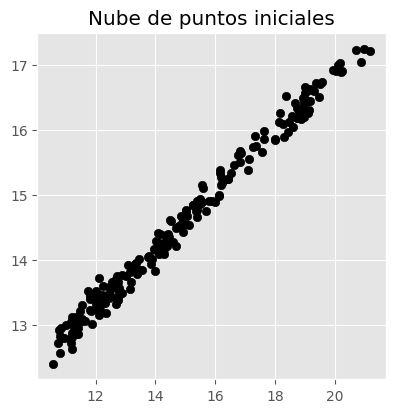

In [1752]:
fig, ax = plt.subplots(1, 1, figsize=(4.5, 4.5))

ax.scatter(
    x = X[:, 0],
    y = X[:, 1],
    c = 'black',
    marker    = 'o',
    edgecolor = 'black'
)
#ax.legend()
ax.set_title('Nube de puntos iniciales')

## Eleccion del mejor escalador:

Antes de usar KMeans para agrupar los datos, primero hay que prepararlos bien. Esto es importante porque KMeans se basa en distancias, y si una variable tiene números mucho más grandes que otra, va a influir más en la agrupación, aunque no sea más importante.

StandardScaler: normaliza los datos para que tengan media 0 y desviación estándar 1. 

MinMaxScaler: transforma los valores para que estén todos entre 0 y 1.

RobustScaler: hace algo parecido, pero ignorando los valores muy extremos o raros (outliers), así que es más resistente a ellos.

In [1753]:
pipeline_standard = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=2))    
])

pipeline_minmax = Pipeline([
    ('scaler', MinMaxScaler()),
    ('pca', PCA(n_components=2))    
])

pipeline_robust = Pipeline([
    ('scaler', RobustScaler()),
    ('pca', PCA(n_components=2))    
])

Después de escalar los datos, se les aplica PCA, una técnica que reduce las variables a solo dos dimensiones. Esto no solo ayuda a simplificar los datos, sino que también nos permite hacer gráficos en 2D para ver si los clusters se forman bien.

In [1754]:
X_pca_standard = pipeline_standard.fit_transform(X)
X_pca_minmax = pipeline_minmax.fit_transform(X)
X_pca_robust = pipeline_robust.fit_transform(X)

Aplicar KMeans por separado a cada conjunto separado


In [1755]:
kmeans_standard = KMeans(n_clusters=3, random_state=100475965).fit(X_pca_standard)
kmeans_minmax = KMeans(n_clusters=3, random_state=100475965).fit(X_pca_minmax)
kmeans_robust = KMeans(n_clusters=3, random_state=100475965).fit(X_pca_robust)

labels_standard = kmeans_standard.labels_
labels_minmax = kmeans_minmax.labels_
labels_robust = kmeans_robust.labels_

In [1756]:
y = data.iloc[:, -1].values  


Text(0, 0.5, 'Componente Principal 2')

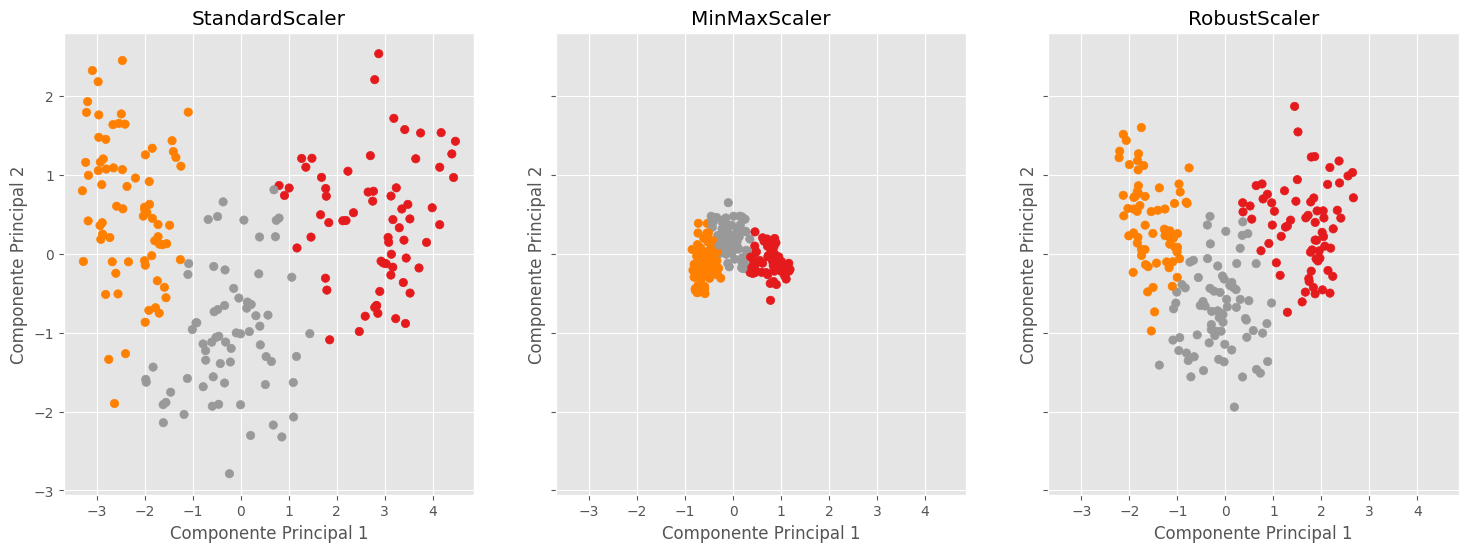

In [1757]:

fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharex=True, sharey=True)

# Gráfica para StandardScaler
axes[0].scatter(
    X_pca_standard[:, 0], X_pca_standard[:, 1],
    c=labels_standard, cmap='Set1'
)
axes[0].set_title('StandardScaler')
axes[0].set_xlabel('Componente Principal 1')
axes[0].set_ylabel('Componente Principal 2')

# Gráfica para MinMaxScaler
axes[1].scatter(
    X_pca_minmax[:, 0], X_pca_minmax[:, 1],
    c=labels_minmax, cmap='Set1'
)
axes[1].set_title('MinMaxScaler')
axes[1].set_xlabel('Componente Principal 1')
axes[1].set_ylabel('Componente Principal 2')

# Gráfica para RobustScaler
axes[2].scatter(
    X_pca_robust[:, 0], X_pca_robust[:, 1],
    c=labels_robust, cmap='Set1'
)
axes[2].set_title('RobustScaler')
axes[2].set_xlabel('Componente Principal 1')
axes[2].set_ylabel('Componente Principal 2')




Hago "zoom" para ver si los clusters en minmax estan separados peor he puesto la dimensió muy grande

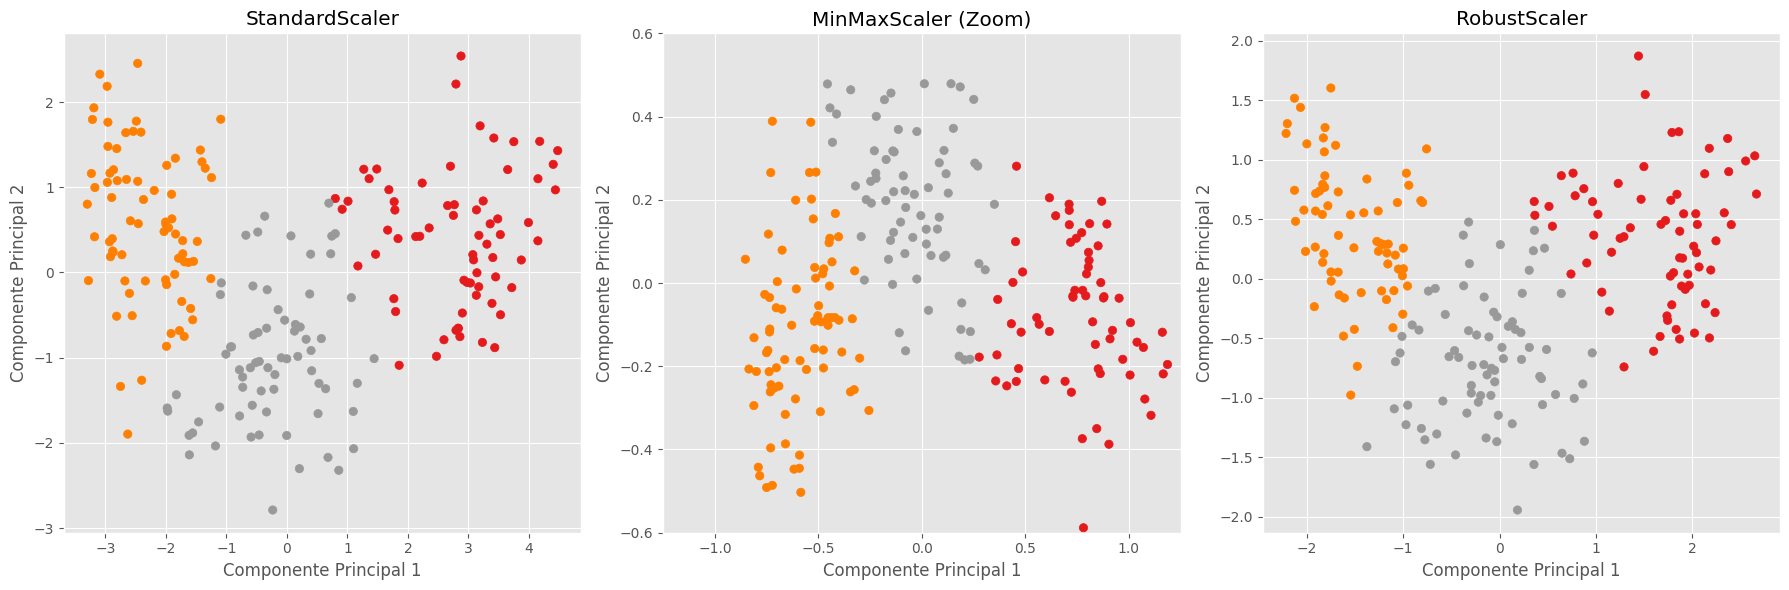

In [1758]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharex=False, sharey=False)

# Gráfica para StandardScaler
axes[0].scatter(
    X_pca_standard[:, 0], X_pca_standard[:, 1],
    c=labels_standard, cmap='Set1'
)
axes[0].set_title('StandardScaler')
axes[0].set_xlabel('Componente Principal 1')
axes[0].set_ylabel('Componente Principal 2')

# Gráfica para MinMaxScaler (con zoom)
axes[1].scatter(
    X_pca_minmax[:, 0], X_pca_minmax[:, 1],
    c=labels_minmax, cmap='Set1'
)
axes[1].set_title('MinMaxScaler (Zoom)')
axes[1].set_xlabel('Componente Principal 1')
axes[1].set_ylabel('Componente Principal 2')
axes[1].set_xlim(-1.25, 1.25)
axes[1].set_ylim(-0.6, 0.6)

# Gráfica para RobustScaler
axes[2].scatter(
    X_pca_robust[:, 0], X_pca_robust[:, 1],
    c=labels_robust, cmap='Set1'
)
axes[2].set_title('RobustScaler')
axes[2].set_xlabel('Componente Principal 1')
axes[2].set_ylabel('Componente Principal 2')

plt.tight_layout()
plt.show()


### Varianza explicadas:
Es el porcentaje de la varianza total del dataset original que está contenida en cada componente principal.

Ejemplo:
Si la varianza explicada por los dos primeros componentes es 0.90 (o 90%), eso significa que con solo dos componentes estamos conservando el 90% de la información del dataset original.

In [1759]:
# Obtener la varianza explicada por cada PCA
explained_variance_standard = pipeline_standard.named_steps['pca'].explained_variance_ratio_
explained_variance_minmax = pipeline_minmax.named_steps['pca'].explained_variance_ratio_
explained_variance_robust = pipeline_robust.named_steps['pca'].explained_variance_ratio_



In [1760]:
print("Varianza explicada con StandardScaler:")
print(explained_variance_standard)


print("\nVarianza explicada con MinMaxScaler:")
print(explained_variance_minmax)


print("\nVarianza explicada con RobustScaler:")
print(explained_variance_robust)

Varianza explicada con StandardScaler:
[0.71874303 0.17108184]

Varianza explicada con MinMaxScaler:
[0.78903362 0.1290949 ]

Varianza explicada con RobustScaler:
[0.66945748 0.19962637]


In [1761]:

suma_standard = explained_variance_standard.sum()
suma_minmax = explained_variance_minmax.sum()
suma_robust = explained_variance_robust.sum()

print(f"StandardScaler - Suma de varianzas explicadas: {suma_standard:.4f}")

print(f"MinMaxScaler - Suma de varianzas explicadas: {suma_minmax:.4f}")

print(f"RobustScaler - Suma de varianzas explicadas: {suma_robust:.4f}")

StandardScaler - Suma de varianzas explicadas: 0.8898
MinMaxScaler - Suma de varianzas explicadas: 0.9181
RobustScaler - Suma de varianzas explicadas: 0.8691


### **Conclusión:**
Solo teniendo en cuenta la suma de las varianzas explicadas, diría que **MinMaxScaler** es el escalador que mejor conserva la información del dataset después de aplicar PCA. Su suma es la más alta (91,81%), lo que significa que los dos primeros componentes principales recogen prácticamente toda la variabilidad de los datos.

Después iría StandardScaler con un 88,98%, y por último RobustScaler con un 86,91%. Aunque no hay una diferencia enorme entre ellos, se nota que MinMaxScaler consigue retener más información al reducir a dos dimensiones.


## KMeans: metodo del codo y silueta


In [1762]:
inertia = []
silhouette = []
K_range = range(2, 10)

In [1763]:
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=100475965)
    kmeans.fit(X_pca_minmax)
    inertia.append(kmeans.inertia_)
    silhouette.append(silhouette_score(X_pca_minmax, kmeans.labels_))


Text(0, 0.5, 'Silhouette Score')

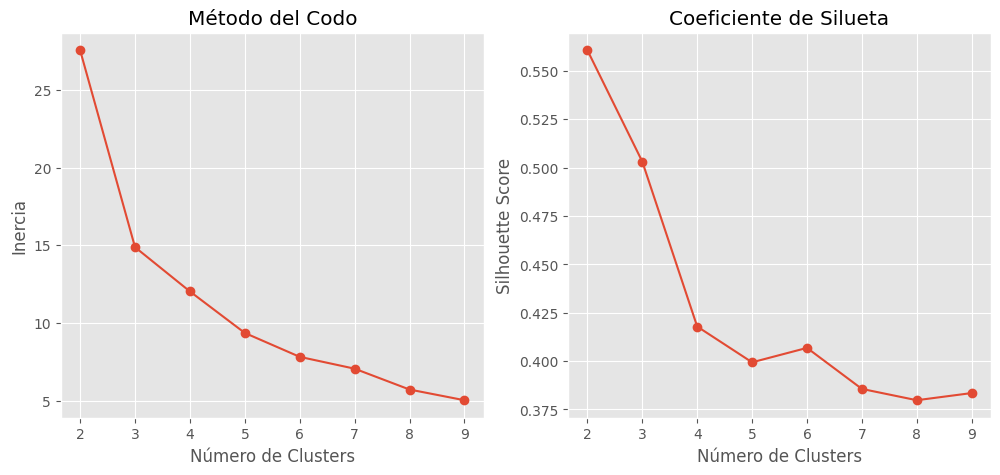

In [1764]:
fig, axs = plt.subplots(1, 2, figsize=(12, 5))
axs[0].plot(K_range, inertia, marker='o')
axs[0].set_title("Método del Codo")
axs[0].set_xlabel("Número de Clusters")
axs[0].set_ylabel("Inercia")

axs[1].plot(K_range, silhouette, marker='o')
axs[1].set_title("Coeficiente de Silueta")
axs[1].set_xlabel("Número de Clusters")
axs[1].set_ylabel("Silhouette Score")

En el método del codo se ve que el mejor vlaor es k=3, donde se encuentra el codo de la función.

Para n_clusters = 2, la media de silhouette_score es: 0.5607
Para n_clusters = 3, la media de silhouette_score es: 0.5032
Para n_clusters = 4, la media de silhouette_score es: 0.4179
Para n_clusters = 5, la media de silhouette_score es: 0.3994
Para n_clusters = 6, la media de silhouette_score es: 0.4068


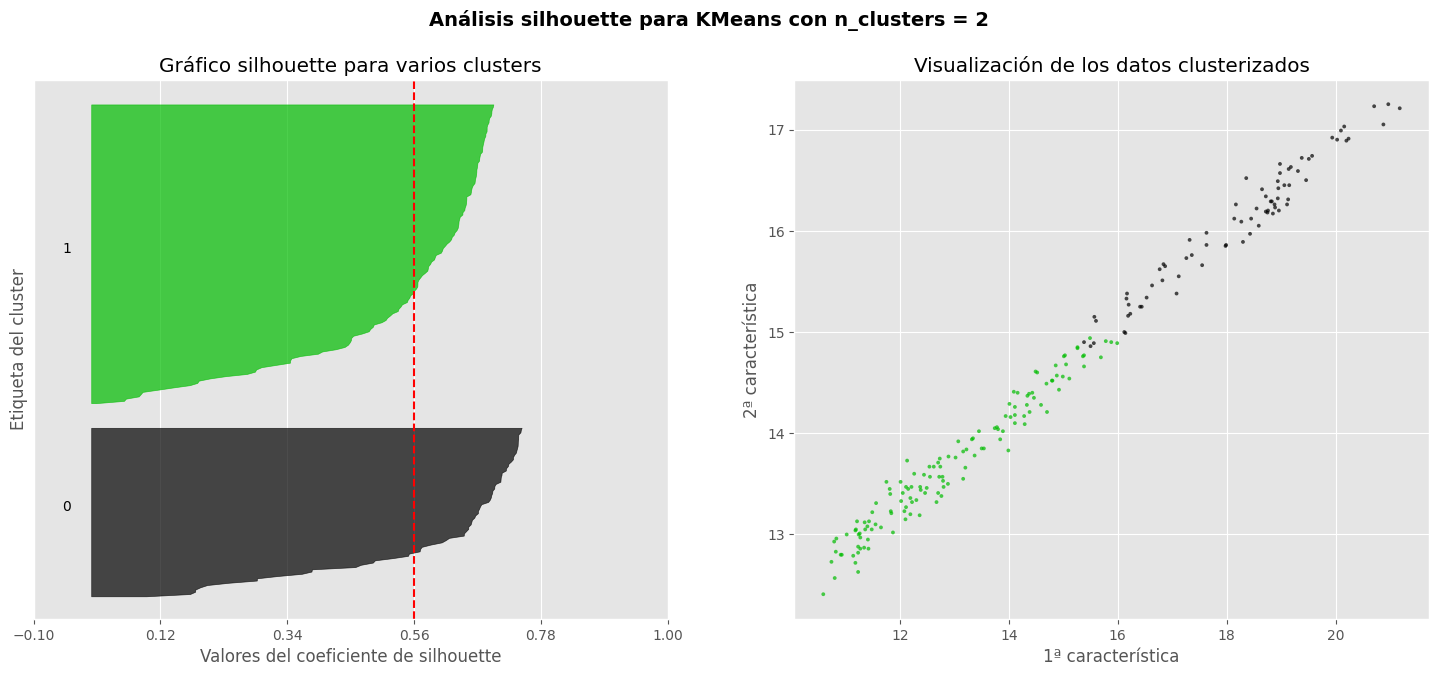

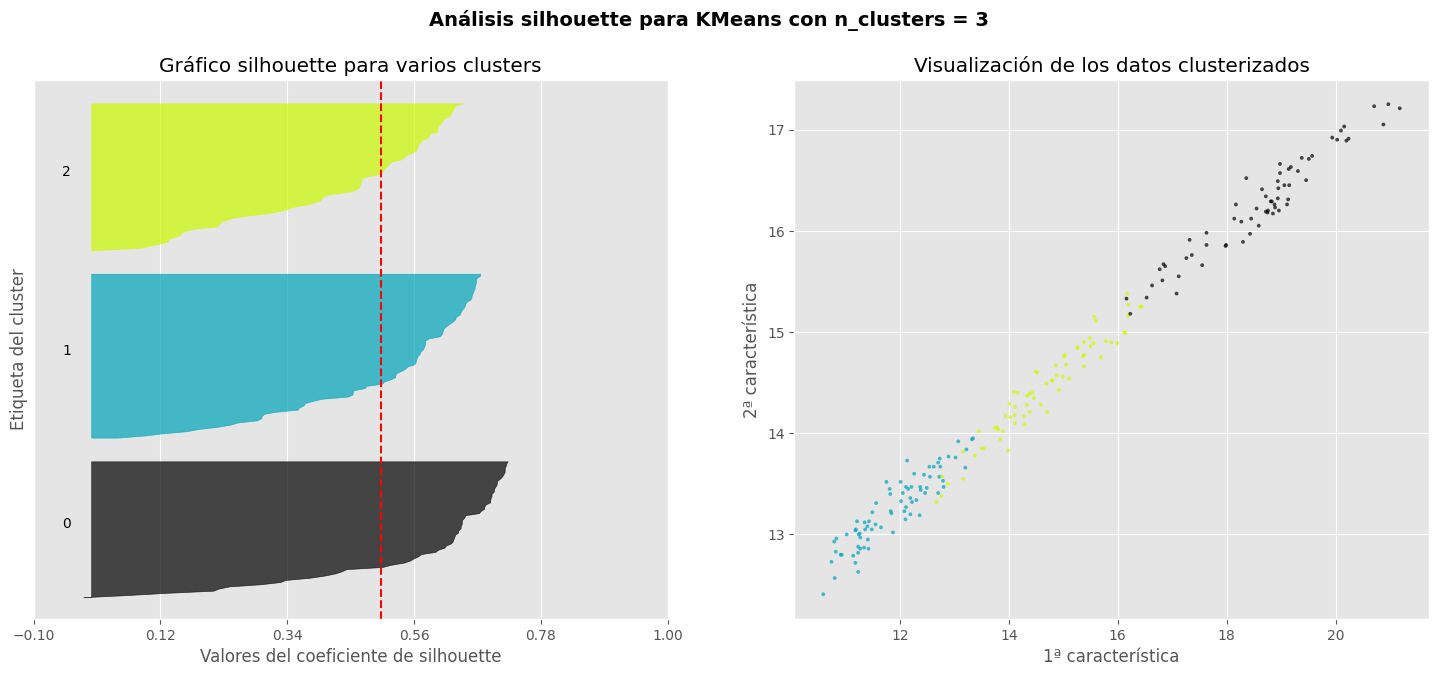

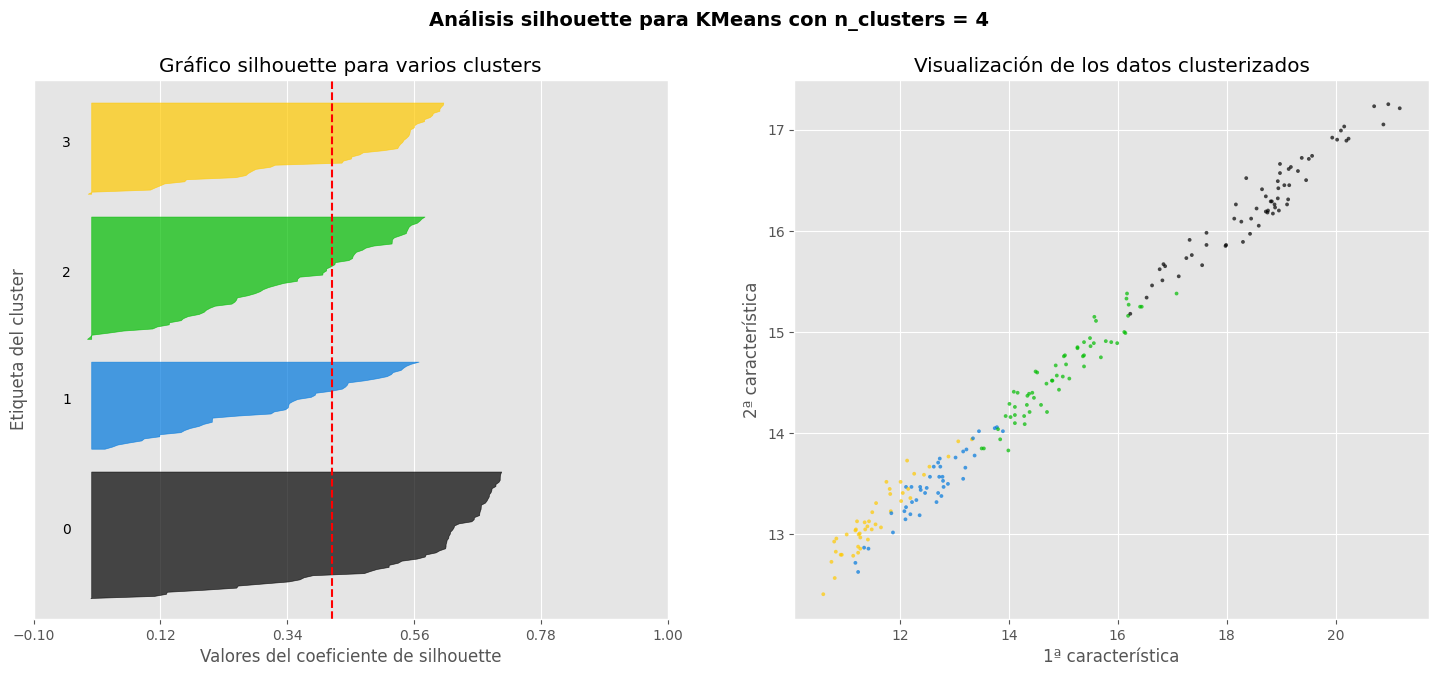

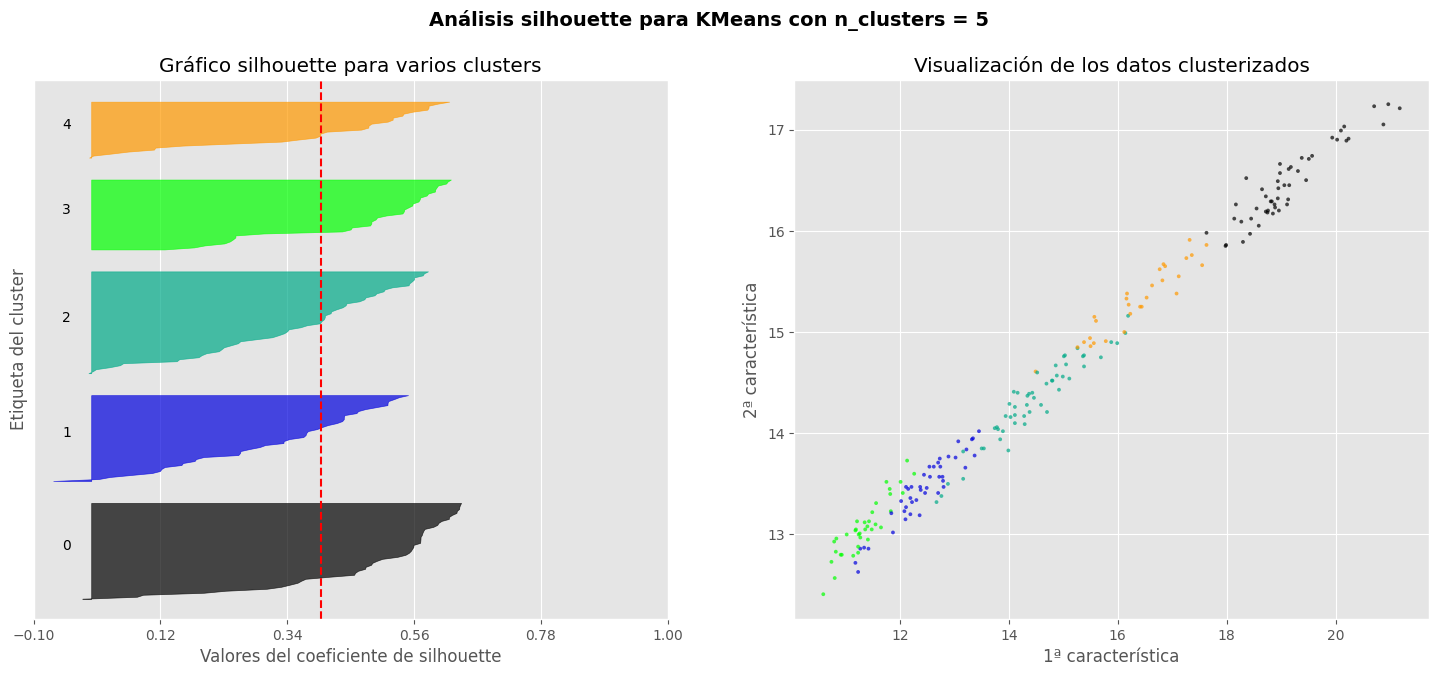

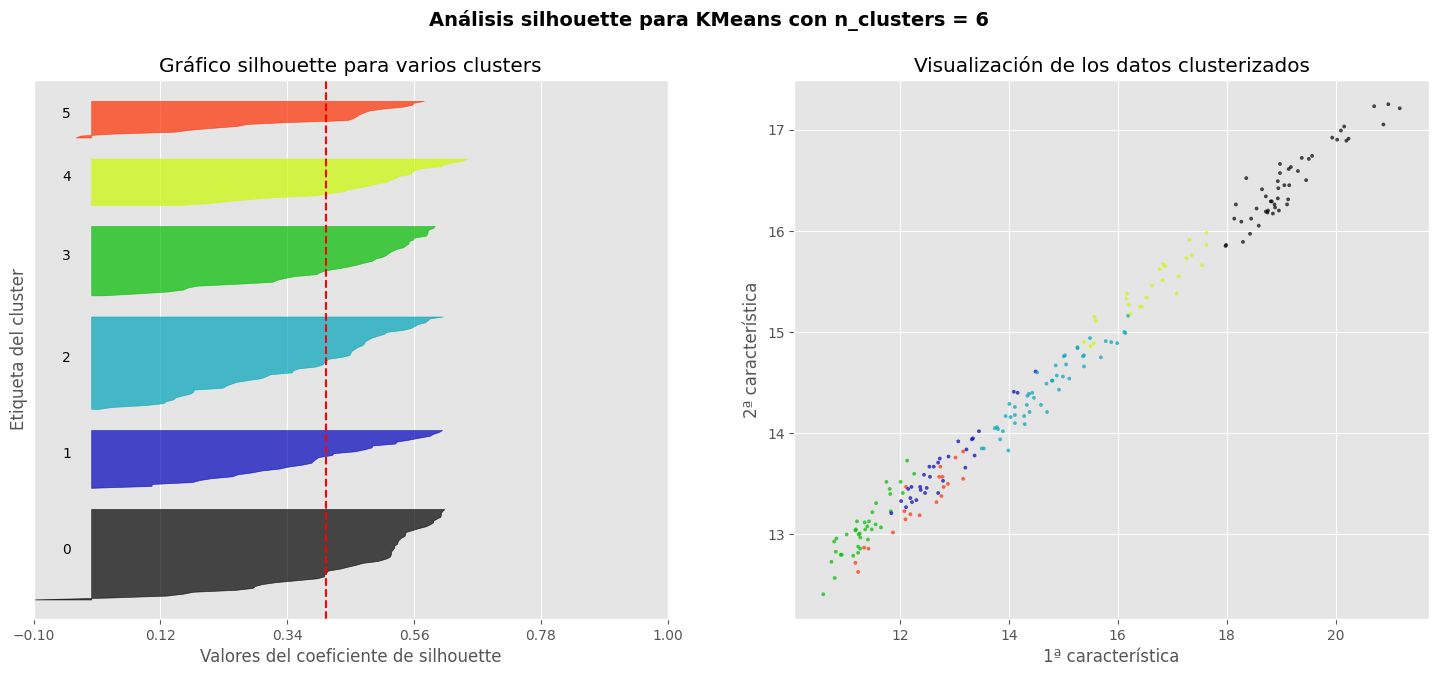

In [1765]:
range_n_clusters = [2, 3, 4, 5, 6]

for n_clusters in range_n_clusters:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

    ax1.set_xlim([-0.1, 1])
    ax1.set_ylim([0, len(X_pca_minmax) + (n_clusters + 1) * 10])

    clusterer = KMeans(n_clusters=n_clusters, random_state=100475965)
    cluster_labels = clusterer.fit_predict(X_pca_minmax)

    silhouette_avg = silhouette_score(X_pca_minmax, cluster_labels)
    print(f"Para n_clusters = {n_clusters}, la media de silhouette_score es: {silhouette_avg:.4f}")

    sample_silhouette_values = silhouette_samples(X_pca_minmax, cluster_labels)

    y_lower = 10
    for i in range(n_clusters):
        ith_cluster_silhouette_values = sample_silhouette_values[cluster_labels == i]
        ith_cluster_silhouette_values.sort()

        size_cluster_i = ith_cluster_silhouette_values.shape[0]
        y_upper = y_lower + size_cluster_i

        color = cm.nipy_spectral(float(i) / n_clusters)
        ax1.fill_betweenx(
            np.arange(y_lower, y_upper),
            0,
            ith_cluster_silhouette_values,
            facecolor=color,
            edgecolor=color,
            alpha=0.7,
        )

        ax1.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))
        y_lower = y_upper + 10

    ax1.set_title("Gráfico silhouette para varios clusters")
    ax1.set_xlabel("Valores del coeficiente de silhouette")
    ax1.set_ylabel("Etiqueta del cluster")
    ax1.axvline(x=silhouette_avg, color="red", linestyle="--")
    ax1.set_yticks([])
    ax1.set_xticks(np.linspace(-0.1, 1.0, 6))

    # Segundo gráfico: representación de los clusters
    colors = cm.nipy_spectral(cluster_labels.astype(float) / n_clusters)
    ax2.scatter(
        X[:, 0], X[:, 1],
        marker=".", s=30, lw=0, alpha=0.7,
        c=colors, edgecolor="k"
    )

    ax2.set_title("Visualización de los datos clusterizados")
    ax2.set_xlabel("1ª característica")
    ax2.set_ylabel("2ª característica")

    plt.suptitle(
        f"Análisis silhouette para KMeans con n_clusters = {n_clusters}",
        fontsize=14,
        fontweight="bold"
    )

plt.show()


Aunque con 2 clusters tenía el silhouette más alto, con 3 clusters consigo separar mejor los datos en grupos más útiles sin perder demasiada calidad. Además, el método del codo también me dio 3 como mejor opción

## K-Means con k=3

In [1766]:
kmeans = KMeans(n_clusters=3, random_state=100475965)
labels_kmeans = kmeans.fit_predict(X_pca_minmax)


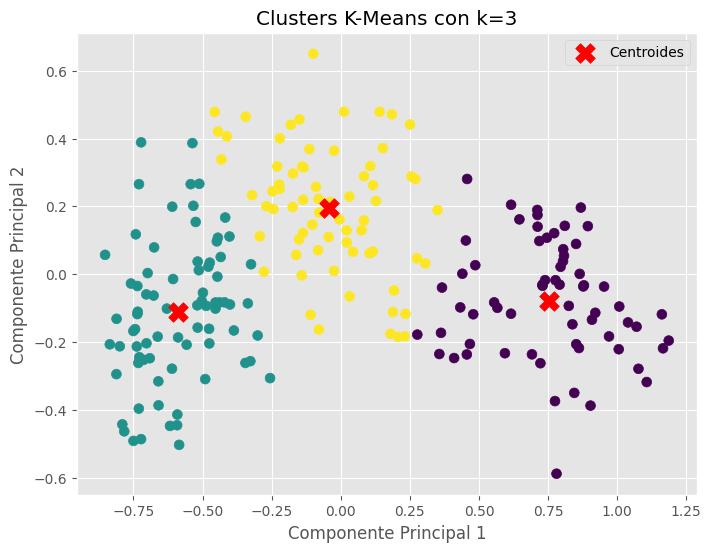

In [1767]:
plt.figure(figsize=(8, 6))
plt.scatter(X_pca_minmax[:, 0], X_pca_minmax[:, 1], c=labels_kmeans, cmap='viridis', s=50)
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1],
            c='red', marker='X', s=200, label='Centroides')
plt.title("Clusters K-Means con k=3")
plt.xlabel("Componente Principal 1")
plt.ylabel("Componente Principal 2")
plt.legend()
plt.show()

### ¿Qué pasaría si el clustering lo hiciese con k= 4 o k=2?

K=4


In [1768]:
kmeans = KMeans(n_clusters=4, random_state=100475965)
labels_kmeans = kmeans.fit_predict(X_pca_minmax)


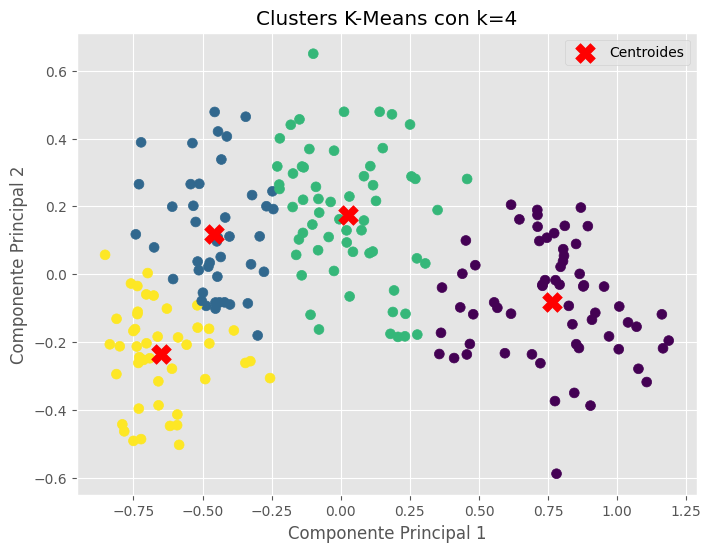

In [1769]:
plt.figure(figsize=(8, 6))
plt.scatter(X_pca_minmax[:, 0], X_pca_minmax[:, 1], c=labels_kmeans, cmap='viridis', s=50)
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1],
            c='red', marker='X', s=200, label='Centroides')
plt.title("Clusters K-Means con k=4")
plt.xlabel("Componente Principal 1")
plt.ylabel("Componente Principal 2")
plt.legend()
plt.show()

Con k=4 aparecen cuatro montones pero uno de ellos es muy pequeño y ‘artificial’, como si el algoritmo estuviera partiendo una clase real en dos subgrupos. El resultado es más confuso: los centros estan muy cerca entre sí y la separación no mejora (incluso baja el silhouette).

K=2

In [1770]:
kmeans = KMeans(n_clusters=2, random_state=100475965)
labels_kmeans = kmeans.fit_predict(X_pca_minmax)


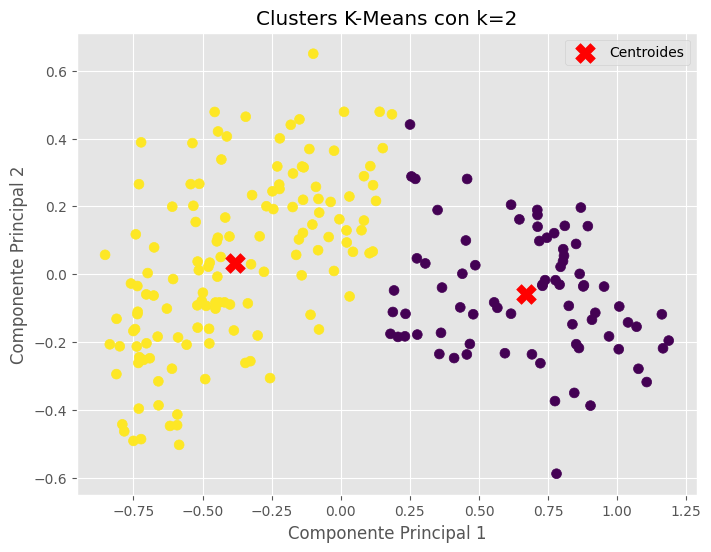

In [1771]:
plt.figure(figsize=(8, 6))
plt.scatter(X_pca_minmax[:, 0], X_pca_minmax[:, 1], c=labels_kmeans, cmap='viridis', s=50)
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1],
            c='red', marker='X', s=200, label='Centroides')
plt.title("Clusters K-Means con k=2")
plt.xlabel("Componente Principal 1")
plt.ylabel("Componente Principal 2")
plt.legend()
plt.show()

Con k=2 se ve que el algoritmo fuerza solo dos grupos y acaba juntando dos clases reales en un mismo cluster. Eso da mucha cohesión interna (silhouette alto) pero pierde detalle: no se disitnguen las tres clases originales.

## Clustering Jerárquico (Dendrograma y agrupamiento)

In [1772]:
def plot_dendrogram(model, **kwargs):
    counts = np.zeros(model.children_.shape[0])
    n_samples = len(model.labels_)
    for i, merge in enumerate(model.children_):
        current_count = 0
        for child_idx in merge:
            if child_idx < n_samples:
                current_count += 1
            else:
                current_count += counts[child_idx - n_samples]
        counts[i] = current_count

    linkage_matrix = np.column_stack([
        model.children_, 
        model.distances_, 
        counts
    ]).astype(float)

    dendrogram(linkage_matrix, **kwargs)


### Dendrograma - Linkage Average

In [1773]:
modelo_hclust_average = AgglomerativeClustering(
    linkage='average',
    distance_threshold=0,
    n_clusters=None,
    compute_distances=True
).fit(X_pca_minmax)


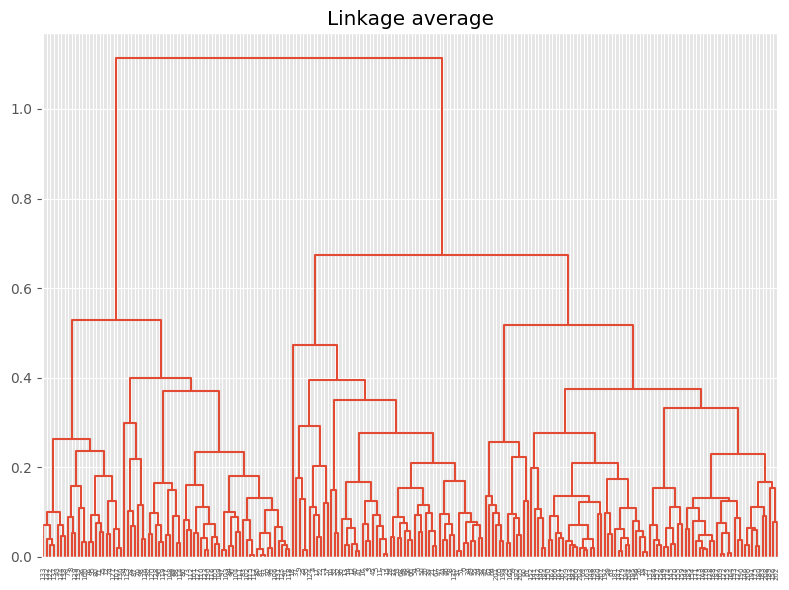

In [1774]:

fig, ax = plt.subplots(figsize=(8, 6))
plot_dendrogram(modelo_hclust_average, labels=np.arange(X_pca_minmax.shape[0]), color_threshold=0, ax=ax)
ax.set_title("Linkage average")
plt.tight_layout()
plt.show()


Al inspeccionar el dendrograma se ve que el salto vertical más grande antes de unir los tres grupos principales es alrededor de 0.6–0.8. Ese “gran hueco” significa que a esa altura se estan mezclando conjuntos muy disímiles, así que al trazar la línea en 0.7 obtengo tres clusters bien diferenciados y sin forzar un corte demasiado bajo (que daría demasiados grupos pequeños) ni demasiado alto (que fundiría en uno solo).

In [1775]:
Z = linkage(X_pca_minmax, method='average')


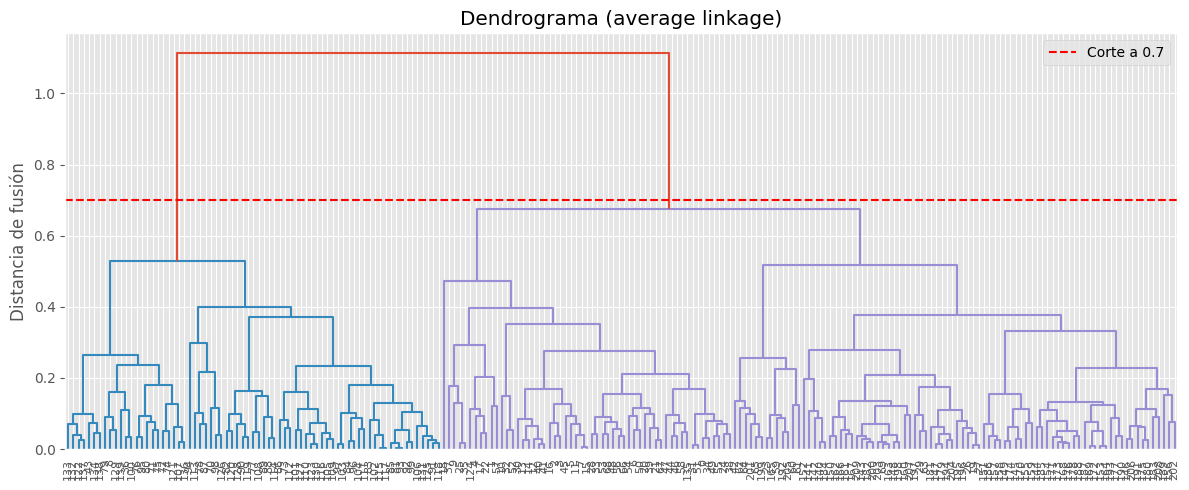

In [1776]:

plt.figure(figsize=(12, 5))
dendrogram(Z, leaf_rotation=90, leaf_font_size=8, color_threshold=0.7)
plt.axhline(y=0.7, c='red', linestyle='--', label='Corte a 0.7')
plt.title('Dendrograma (average linkage)')
plt.ylabel('Distancia de fusión')
plt.legend()
plt.tight_layout()
plt.show()

clusters_hier = fcluster(Z, t=0.7, criterion='distance')


Los grupos se van formando de manera progresiva, sin saltos muy grandes. Aunque no es muy evidente, considero razonable pensar en unas 3 agrupaciones principales.

### Dendrograma - Linkage Complete

In [1777]:
modelo_hclust_complete = AgglomerativeClustering(
    linkage='complete',
    distance_threshold=0,
    n_clusters=None,
    compute_distances=True
).fit(X_pca_minmax)


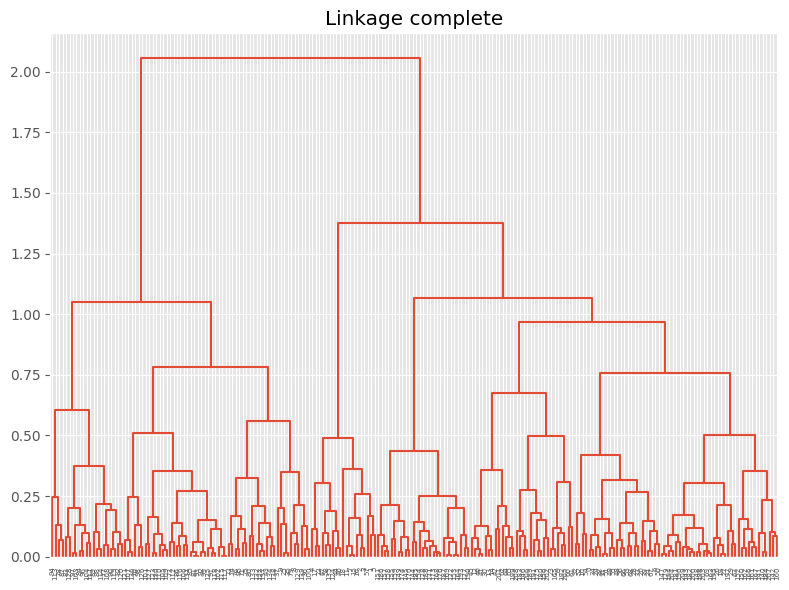

In [1778]:

fig, ax = plt.subplots(figsize=(8, 6))
plot_dendrogram(modelo_hclust_complete, labels=np.arange(X_pca_minmax.shape[0]), color_threshold=0, ax=ax)
ax.set_title("Linkage complete")
plt.tight_layout()
plt.show()


In [1779]:
Z = linkage(X_pca_minmax, method='complete')

In [1780]:
clusters_hier = fcluster(Z, t=0.7, criterion='distance')

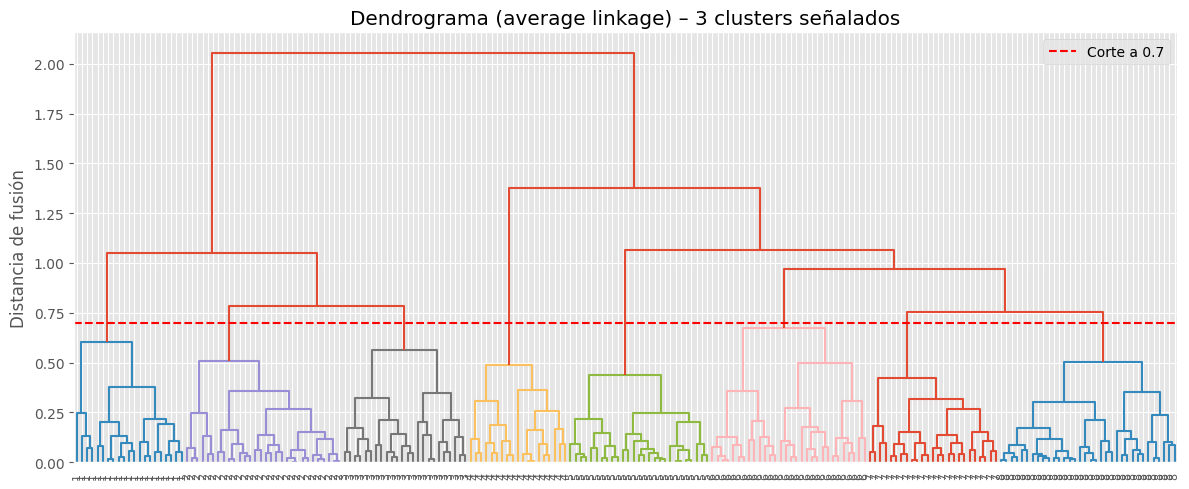

1    21
2    30
3    24
4    19
5    27
6    30
7    25
8    34
Name: count, dtype: int64


In [1781]:

plt.figure(figsize=(12, 5))
dendrogram(
    Z,
    labels=clusters_hier,         
    leaf_rotation=90,
    leaf_font_size=8,
    color_threshold=0.7         
)
plt.axhline(y=0.7, c='red', linestyle='--', label='Corte a 0.7')
plt.title('Dendrograma (average linkage) – 3 clusters señalados')
plt.ylabel('Distancia de fusión')
plt.legend()
plt.tight_layout()
plt.show()

print(pd.Series(clusters_hier).value_counts().sort_index())


El dendrograma muestra saltos más marcados, y se nota que cortar en 3 ramas tendría bastante sentido porque después las distancias crecen bastante.

### Dendrograma - Linkage Ward

In [1782]:
modelo_hclust_ward = AgglomerativeClustering(
    linkage='ward',
    distance_threshold=0,
    n_clusters=None,
    compute_distances=True
).fit(X_pca_minmax)


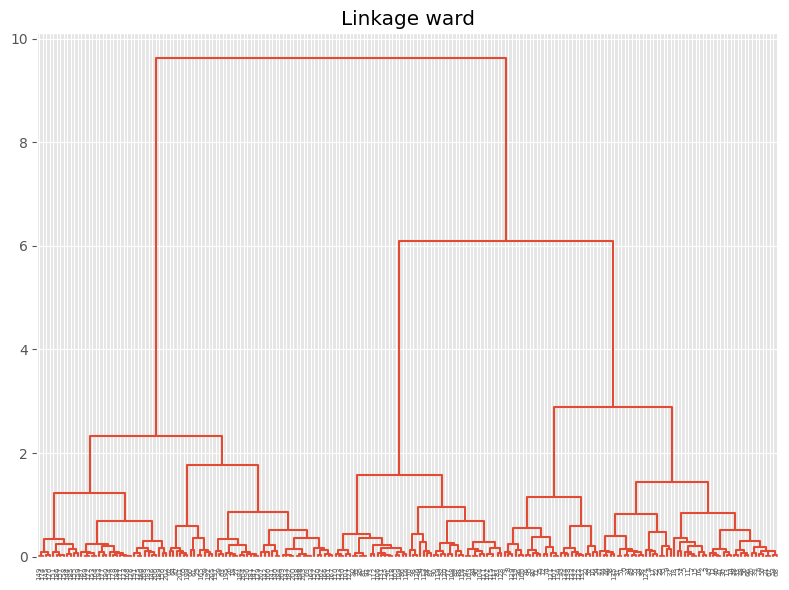

In [1783]:

fig, ax = plt.subplots(figsize=(8, 6))
plot_dendrogram(modelo_hclust_ward, labels=np.arange(X_pca_minmax.shape[0]), color_threshold=0, ax=ax)
ax.set_title("Linkage ward")
plt.tight_layout()
plt.show()


Porque en el eje vertical se ve un gran “salto”: fusionar por encima de 6 implicaría juntar grupos muy disímiles, y por debajo de 6 habría más de tres sub‐ramas. 

In [1784]:
Z_ward = linkage(X_pca_minmax, method='ward')

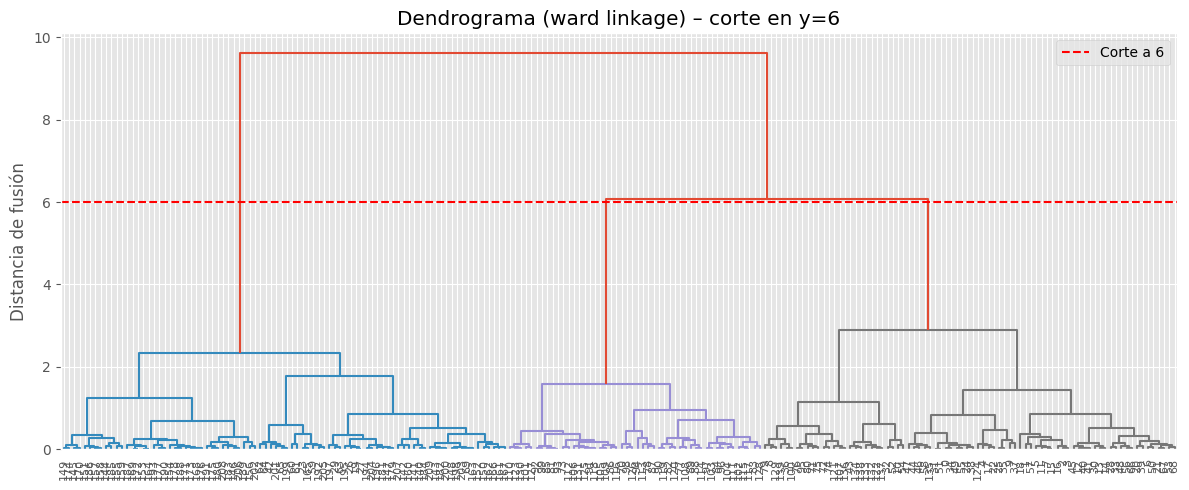

In [1785]:
plt.figure(figsize=(12, 5))
dendrogram(
    Z_ward,
    leaf_rotation=90,
    leaf_font_size=8,
    color_threshold=6    # colorea automáticamente las ramas bajo ese umbral
)
plt.axhline(y=6, c='red', linestyle='--', label='Corte a 6')
plt.title('Dendrograma (ward linkage) – corte en y=6')
plt.ylabel('Distancia de fusión')
plt.legend()
plt.tight_layout()
plt.show()


In [1786]:
clusters_ward = fcluster(Z_ward, t=6, criterion='distance')
print(pd.Series(clusters_ward).value_counts().sort_index())

1    84
2    48
3    78
Name: count, dtype: int64


El agrupamiento es todavía más claro: hay un salto muy grande entre el primer y el segundo nivel de fusión. Aquí cortar en 3 grupos es lo más natural.

**Eleccion de dendograma:**
El dendrograma ward me parece el más claro, con tres ramas bien definidas que se separan a una altura bastante razonable. No se ven saltos bruscos ni fusiones raras, así que da la sensación de que los grupos se han ido formando de forma natural y progresiva. Además, es el más equilibrado visualmente, lo que me hace pensar que los clusters tienen tamaños y formas similares.

En cambio, el dendrograma complete se ve más desequilibrado, como si hubiera un grupo muy grande y otros más pequeños, lo que podría indicar que no hay tanta separación entre los datos. Y el average tiene una estructura más binaria, así que quizás lo ideal en ese caso sería quedarse con solo dos clusters. Si se fuerza a sacar tres, puede que uno de ellos se esté dividiendo artificialmente.

##### **Estudio índice silhouette**

In [1787]:
range_n_clusters = range(2, 15)
valores_medios_silhouette = []


In [1788]:
for n_clusters in range_n_clusters:
    modelo = AgglomerativeClustering(
        linkage='ward',
        n_clusters=n_clusters
    )
    cluster_labels = modelo.fit_predict(X_pca_minmax)
    silhouette_avg = silhouette_score(X_pca_minmax, cluster_labels)
    valores_medios_silhouette.append(silhouette_avg)

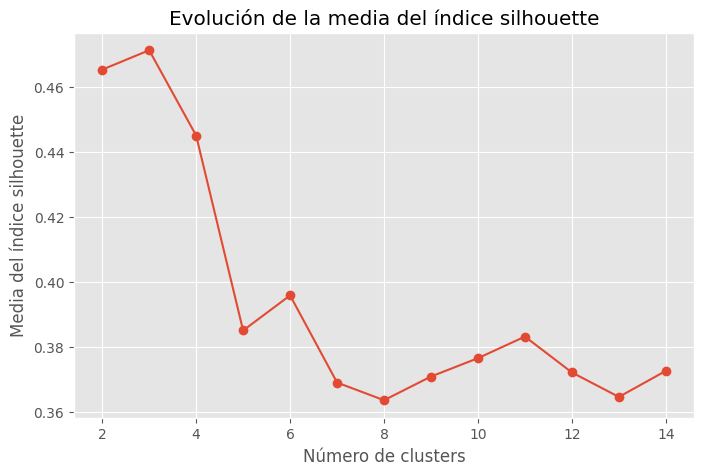

In [1789]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(range_n_clusters, valores_medios_silhouette, marker='o')
ax.set_title("Evolución de la media del índice silhouette")
ax.set_xlabel('Número de clusters')
ax.set_ylabel('Media del índice silhouette')
ax.grid(True)
plt.show()


Después de analizar el gráfico de evolución del índice silhouette, veo que los mejores valores se consiguen con 2 y 3 clusters. A partir de 4 clusters, el índice cae de forma clara y no vuelve a recuperarse, lo que indica que dividir más los datos no mejora el agrupamiento.


### Interpretación de los dendrogramas

En resumen, **los tres métodos apuntan a que 3 clusters es una buena opción**, además con los resultados obtenido en el gráfico silhoutte se confirma que 3 es el numero de clusters que mejor se adapta a mis datos.


### Modelo final

In [1790]:
modelo_hclust_ward = AgglomerativeClustering(
    linkage  = 'ward',
    n_clusters = 3
)
modelo_hclust_ward.fit(X=X_pca_minmax)

AgglomerativeClustering(n_clusters=3)

## DBSCAN 


Para este modelo primero hice una prueba con valores "por defecto" cogiendo eps de 0.3 y min_samples de 5. Para ajustar estas variables fui probando diferentes valores de min_samples y lueogo estimaba el valor del eps mas adecuado. 
Probé con min_samples igual a 14,10,8,7,6,5 y 4. Después dejo los que me dan mejor score de silhutte para cada min_sample.

In [1791]:
min_samples = 4

In [1792]:
vecinos = NearestNeighbors(n_neighbors=min_samples)
vecinos_fit = vecinos.fit(X_pca_minmax)
distancias, indices = vecinos_fit.kneighbors(X_pca_minmax)

In [1793]:
distancias = np.sort(distancias[:, min_samples-1])

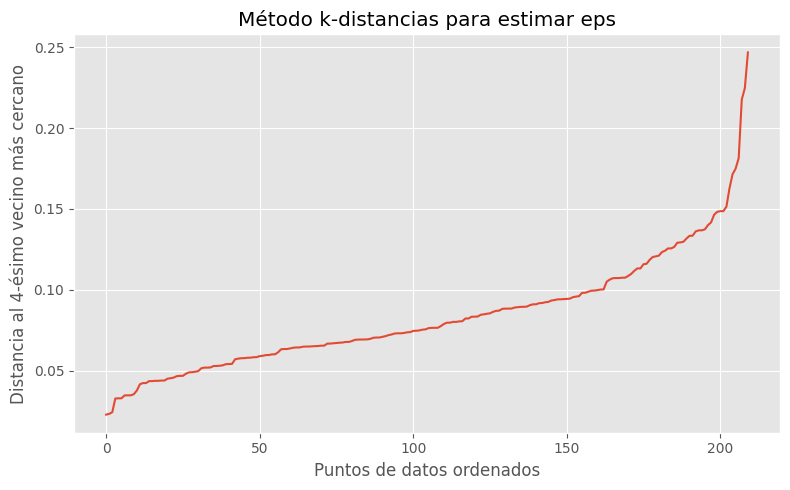

In [1794]:
plt.figure(figsize=(8, 5))
plt.plot(distancias)
plt.title('Método k-distancias para estimar eps')
plt.xlabel('Puntos de datos ordenados')
plt.ylabel(f'Distancia al {min_samples}-ésimo vecino más cercano')
plt.grid(True)
plt.tight_layout()
plt.show()


In [1795]:
min_samples = 5

In [1796]:
vecinos = NearestNeighbors(n_neighbors=min_samples)
vecinos_fit = vecinos.fit(X_pca_minmax)
distancias, indices = vecinos_fit.kneighbors(X_pca_minmax)

In [1797]:
distancias = np.sort(distancias[:, min_samples-1])

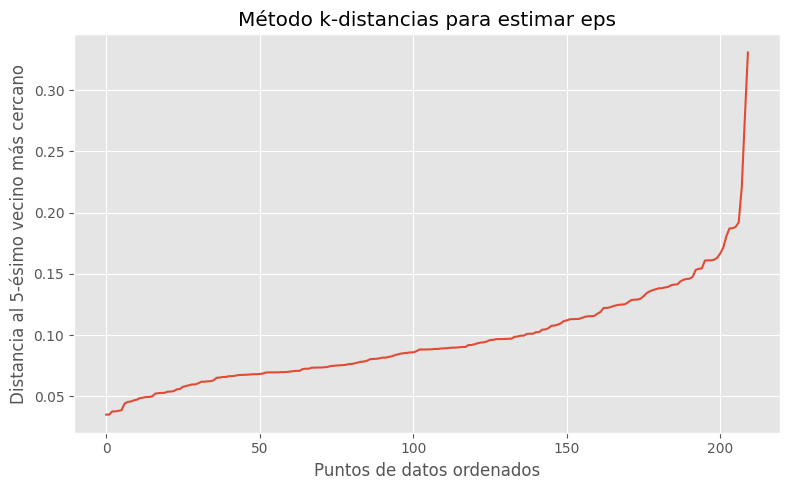

In [1798]:
plt.figure(figsize=(8, 5))
plt.plot(distancias)
plt.title('Método k-distancias para estimar eps')
plt.xlabel('Puntos de datos ordenados')
plt.ylabel(f'Distancia al {min_samples}-ésimo vecino más cercano')
plt.grid(True)
plt.tight_layout()
plt.show()


In [1799]:
min_samples = 6

In [1800]:
vecinos = NearestNeighbors(n_neighbors=min_samples)
vecinos_fit = vecinos.fit(X_pca_minmax)
distancias, indices = vecinos_fit.kneighbors(X_pca_minmax)

In [1801]:
distancias = np.sort(distancias[:, min_samples-1])

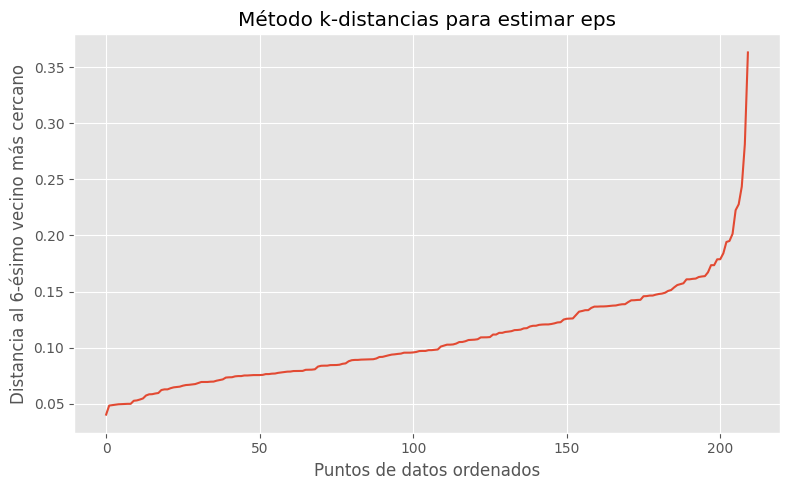

In [1802]:
plt.figure(figsize=(8, 5))
plt.plot(distancias)
plt.title('Método k-distancias para estimar eps')
plt.xlabel('Puntos de datos ordenados')
plt.ylabel(f'Distancia al {min_samples}-ésimo vecino más cercano')
plt.grid(True)
plt.tight_layout()
plt.show()

In [1803]:
min_samples = 8

In [1804]:
vecinos = NearestNeighbors(n_neighbors=min_samples)
vecinos_fit = vecinos.fit(X_pca_minmax)
distancias, indices = vecinos_fit.kneighbors(X_pca_minmax)

In [1805]:
distancias = np.sort(distancias[:, min_samples-1])

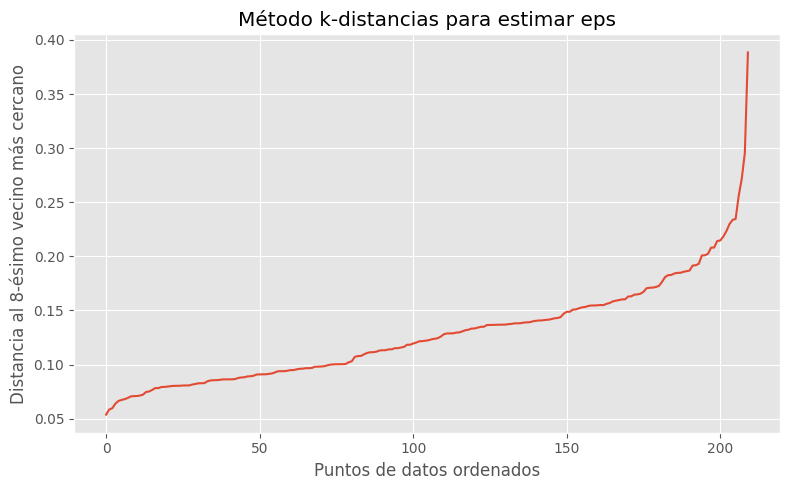

In [1806]:
plt.figure(figsize=(8, 5))
plt.plot(distancias)
plt.title('Método k-distancias para estimar eps')
plt.xlabel('Puntos de datos ordenados')
plt.ylabel(f'Distancia al {min_samples}-ésimo vecino más cercano')
plt.grid(True)
plt.tight_layout()
plt.show()

In [1807]:
def sil_score_sin_ruido(X, labels):
    # Filtrar outliers
    mask = labels != -1
    if len(set(labels[mask])) <= 1:
        return -1  
    return silhouette_score(X[mask], labels[mask])

In [1808]:

# DBSCAN con eps = 0.12
dbscan_0124 = DBSCAN(eps=0.12, min_samples=4)
labels_0124 = dbscan_0124.fit_predict(X_pca_minmax)
score_0124 = sil_score_sin_ruido(X_pca_minmax, labels_0124)

# DBSCAN con eps = 0.12
dbscan_013 = DBSCAN(eps=0.12, min_samples=5)
labels_013 = dbscan_013.fit_predict(X_pca_minmax)
score_013 = sil_score_sin_ruido(X_pca_minmax, labels_013)

# DBSCAN con eps = 0.14
dbscan_014 = DBSCAN(eps=0.14, min_samples=7)
labels_014 = dbscan_014.fit_predict(X_pca_minmax)
score_014 = sil_score_sin_ruido(X_pca_minmax, labels_014)


# DBSCAN con eps = 0.10
dbscan_0156 = DBSCAN(eps=0.10, min_samples=6)
labels_0156 = dbscan_0156.fit_predict(X_pca_minmax)
score_0156 = sil_score_sin_ruido(X_pca_minmax, labels_0156)

# DBSCAN con eps = 0.10
dbscan_015 = DBSCAN(eps=0.11, min_samples=8)
labels_015 = dbscan_015.fit_predict(X_pca_minmax)
score_015 = sil_score_sin_ruido(X_pca_minmax, labels_015)



In [1809]:

print(f"Silhouette score con eps = 0.12 con 4: {score_0124:.4f}") #THE BEST
print(f"Silhouette score con eps = 0.12 con 5: {score_013:.4f}") #THE BEST
print(f"Silhouette score con eps = 0.10 con 6: {score_0156:.4f}")
print(f"Silhouette score con eps = 0.14 con 7 : {score_014:.4f}") #THE BEST
print(f"Silhouette score con eps = 0.11 con 8 : {score_015:.4f}") #THE BEST

Silhouette score con eps = 0.12 con 4: 0.4337
Silhouette score con eps = 0.12 con 5: 0.4360
Silhouette score con eps = 0.10 con 6: 0.5791
Silhouette score con eps = 0.14 con 7 : 0.4957
Silhouette score con eps = 0.11 con 8 : 0.5803


Aunque tanto KMeans como el clustering jerárquico me han dado que la estructura natural del dataset está compuesta por 3 clusters al aplicar DBSCAN los resultados han sido distintos. Tras ajustar los hiperparámetros, la configuración que mejor rendimiento ha mostrado ha sido con eps = 0.14 y min_samples = 7, que produce 2 clusters, con un silhouette score de 0.4957 y apenas 9 outliers. 

Probé otras combinaciones de parámetros, como eps = 0.10 con min_samples = 6, que daban un silhouette score aún mayor (0.5791), pero a costa de identificar 4 clusters y marcar 61 puntos como outliers, lo cual considero excesivo para este conjunto de datos y menos útil a nivel interpretativo. Pasaba lo mismo usanto eps = 0.11 con min_samples = 8.

También ajusté los parámetros para obtener justo 3 clusters, como eps = 0.12 y min_samples = 4, pero el resultado fue un silhouette score menor (0.43) y un número de outliers más alto (28) que en la solución de 2 clusters, lo que indica una agrupación menos definida.

### *Ajuste:* 
Voy a repetir el estudio de eps y min_samples, pero ahora con ruido porque me he dado cuenta de que en los otros dos casos (KMeans y dendogramas), en mis tablas comparativas (más adelante) estudio el score de siuleta con ruido y queior que la comparación sea lo más realista posible.

In [1810]:
def sil_score_con_ruido(X, labels):
    if len(set(labels)) <= 1:
        return -1
    return silhouette_score(X, labels)


In [1811]:
# DBSCAN con eps = 0.12
dbscan_0124 = DBSCAN(eps=0.12, min_samples=4)
labels_0124 = dbscan_0124.fit_predict(X_pca_minmax)
score_0124 = sil_score_con_ruido(X_pca_minmax, labels_0124)

# DBSCAN con eps = 0.12
dbscan_013 = DBSCAN(eps=0.12, min_samples=5)
labels_013 = dbscan_013.fit_predict(X_pca_minmax)
score_013 = sil_score_con_ruido(X_pca_minmax, labels_013)

# DBSCAN con eps = 0.14
dbscan_014 = DBSCAN(eps=0.14, min_samples=7)
labels_014 = dbscan_014.fit_predict(X_pca_minmax)
score_014 = sil_score_con_ruido(X_pca_minmax, labels_014)


# DBSCAN con eps = 0.10
dbscan_0156 = DBSCAN(eps=0.10, min_samples=6)
labels_0156 = dbscan_0156.fit_predict(X_pca_minmax)
score_0156 = sil_score_con_ruido(X_pca_minmax, labels_0156)

# DBSCAN con eps = 0.10
dbscan_015 = DBSCAN(eps=0.11, min_samples=8)
labels_015 = dbscan_015.fit_predict(X_pca_minmax)
score_015 = sil_score_con_ruido(X_pca_minmax, labels_015)

In [1812]:

print(f"Silhouette score con eps = 0.12 con 4: {score_0124:.4f}") 
print(f"Silhouette score con eps = 0.12 con 5: {score_013:.4f}") 
print(f"Silhouette score con eps = 0.10 con 6: {score_0156:.4f}")
print(f"Silhouette score con eps = 0.14 con 7 : {score_014:.4f}")
print(f"Silhouette score con eps = 0.11 con 8 : {score_015:.4f}")

Silhouette score con eps = 0.12 con 4: 0.3529
Silhouette score con eps = 0.12 con 5: 0.3348
Silhouette score con eps = 0.10 con 6: 0.2541
Silhouette score con eps = 0.14 con 7 : 0.3259
Silhouette score con eps = 0.11 con 8 : 0.1528


DBSCAN funciona bien en mi conjunto de datos cuando el valor de eps se sitúa en torno a 0.12 y min_samples entre 4 y 5. Sin embargo, su rendimiento disminuye al hacer más estricta la densidad (aumentando min_samples) o al reducir demasiado el radio de vecindad (eps)

Representación del número de clusters 

In [1813]:

eps_values = np.arange(0.10, 0.30, 0.01)
min_samples_values = range(3, 10)

cluster_matrix = []

In [1814]:
for min_samples in min_samples_values:
    row = []
    for eps in eps_values:
        db = DBSCAN(eps=eps, min_samples=min_samples)
        labels = db.fit_predict(X_pca_minmax)
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        row.append(n_clusters)
    cluster_matrix.append(row)


In [1815]:

df_clusters = pd.DataFrame(cluster_matrix, index=min_samples_values, columns=np.round(eps_values, 2))

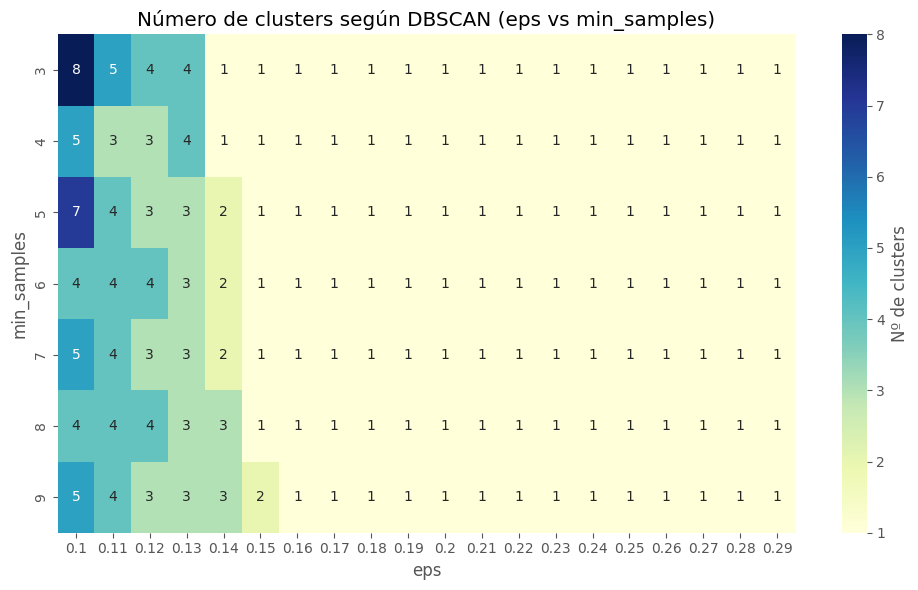

In [1816]:

plt.figure(figsize=(10, 6))
sns.heatmap(df_clusters, annot=True, fmt="d", cmap="YlGnBu", cbar_kws={'label': 'Nº de clusters'})
plt.title("Número de clusters según DBSCAN (eps vs min_samples)")
plt.xlabel("eps")
plt.ylabel("min_samples")
plt.tight_layout()
plt.show()


En el heatmap se ve que los valores más estables y razonables están entre eps = 0.12 y min_samples = 4–5, donde DBSCAN detecta 3–4 clusters. Si eps es demasiado pequeño, aparecen demasiados clusters, y si es muy grande, todo se agrupa en uno solo. Finalmente, y tras haber hecho el estudio de silueta con ruido, me decanto por **eps = 0.12 y min_samples = 4**

In [1817]:
modelo_dbscan = DBSCAN(
    eps          = 0.12,
    min_samples  = 4,
    metric       = 'euclidean',
)

modelo_dbscan.fit(X=X_pca_minmax)

DBSCAN(eps=0.12, min_samples=4)

Text(0.5, 1.0, 'Clusterings generados por DBSCAN')

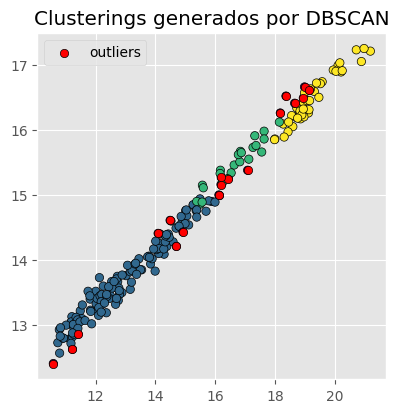

In [1818]:
labels_dbscan = modelo_dbscan.labels_

fig, ax = plt.subplots(1, 1, figsize=(4.5, 4.5))

ax.scatter(
    x = X[:, 0],
    y = X[:, 1],
    c = labels_dbscan,
    marker    = 'o',
    edgecolor = 'black'
)
ax.scatter(
    x = X[labels_dbscan == -1, 0],
    y = X[labels_dbscan == -1, 1],
    c = 'red',
    marker    = 'o',
    edgecolor = 'black',
    label = 'outliers'
)

ax.legend()
ax.set_title('Clusterings generados por DBSCAN')


In [1819]:
n_clusters = len(set(labels_dbscan)) - (1 if -1 in labels_dbscan else 0)
n_noise    = list(labels_dbscan).count(-1)

print(f'Número de clusters encontrados: {n_clusters}')
print(f'Número de outliers encontrados: {n_noise}')

Número de clusters encontrados: 3
Número de outliers encontrados: 18


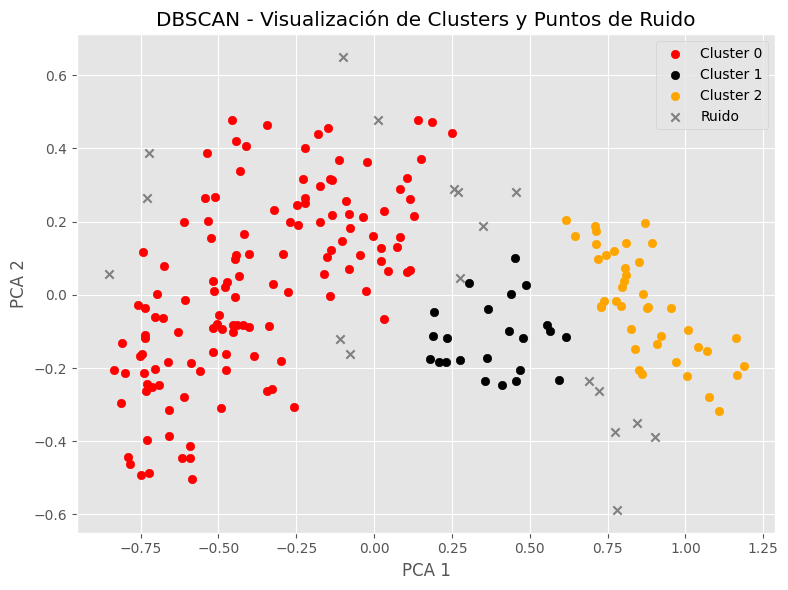

In [1820]:
is_noise = labels_dbscan == -1
colores = ['red', 'black', 'orange', 'yellow'] 

etiquetas_clusters = np.unique(labels_dbscan[~is_noise])
plt.figure(figsize=(8, 6))


for i, cluster_id in enumerate(etiquetas_clusters):
    puntos = X_pca_minmax[labels_dbscan == cluster_id]
    plt.scatter(puntos[:, 0], puntos[:, 1], color=colores[i % len(colores)], label=f'Cluster {cluster_id}')
plt.scatter(X_pca_minmax[is_noise, 0], X_pca_minmax[is_noise, 1],
            c='grey', marker='x', label='Ruido')

plt.title('DBSCAN - Visualización de Clusters y Puntos de Ruido')
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Comparativa visual de KMeans, Jerárquico y DBSCAN corregido

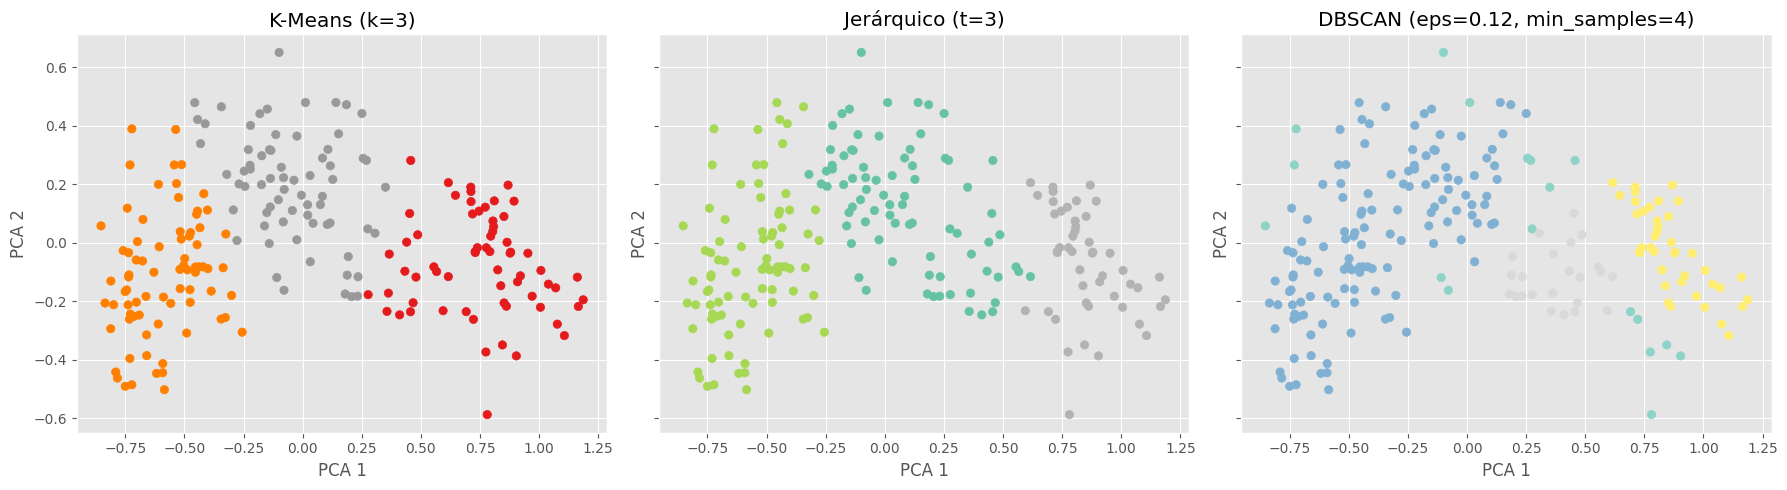

In [1821]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharex=True, sharey=True)


# K-Means con k=3
kmeans_final = KMeans(n_clusters=3, random_state=100475965)
labels_kmeans = kmeans_final.fit_predict(X_pca_minmax)
axes[0].scatter(X_pca_minmax[:, 0], X_pca_minmax[:, 1], c=labels_kmeans, cmap='Set1')
axes[0].set_title('K-Means (k=3)')

# Jerárquico
hierarchical = AgglomerativeClustering(n_clusters=3)
labels_hierarchical = hierarchical.fit_predict(X_pca_minmax)
axes[1].scatter(X_pca_minmax[:, 0], X_pca_minmax[:, 1], c=labels_hierarchical, cmap='Set2')
axes[1].set_title('Jerárquico (t=3)')

# DBSCAN
axes[2].scatter(X_pca_minmax[:, 0], X_pca_minmax[:, 1], c=labels_dbscan, cmap='Set3')
axes[2].set_title('DBSCAN (eps=0.12, min_samples=4)')

for ax in axes:
    ax.set_xlabel('PCA 1')
    ax.set_ylabel('PCA 2')

plt.tight_layout()
plt.show()

### Tabla comparativa de Silhouette Score 


KMeans con k=3

In [1822]:
kmeans = KMeans(n_clusters=3, random_state=100475965)
labels_kmeans = kmeans.fit_predict(X_pca_minmax)

Clustering jerárquico con corte en 3 clusters

In [1823]:
Z = linkage(X_pca_minmax, method='ward')
labels_hierarchical = fcluster(Z, t=3, criterion='maxclust')

DBSCAN

In [1824]:
dbscan = DBSCAN(eps=0.12, min_samples=4)
labels_dbscan = dbscan.fit_predict(X_pca_minmax)

Calcular silueta

In [1825]:
def sil_score_safe(X, labels):
    if len(set(labels)) > 1 and not all(label == -1 for label in labels):
        return silhouette_score(X, labels)
    else:
        return "No válido (ruido o 1 cluster)"

In [1826]:
silhouette_results = {
    'Método': ['K-Means (k=3)', 'Jerárquico (t=3)', 'DBSCAN (eps=0.12, min=4)'],
    'Silhouette Score': [
        sil_score_safe(X_pca_minmax, labels_kmeans),
        sil_score_safe(X_pca_minmax, labels_hierarchical),
        sil_score_safe(X_pca_minmax, labels_dbscan)
    ]
}

df_silhouette = pd.DataFrame(silhouette_results)
display(df_silhouette)


,Método,Silhouette Score
0,K-Means (k=3),0.503160
1,Jerárquico (t=3),0.471405
2,"DBSCAN (eps=0.12, min=4)",0.352858


K-Means es el que mejor separa los datos según la métrica de silhouette, seguido de cerca por el clustering jerárquico. DBSCAN agrupa menos homogéneamente. Si mi objetivo es maximizar la cohesión y separación interna, K-Means k=3 es la mejor opción.

## Histograma comparativo

In [1827]:

metodos = ['K-Means (k=3)', 'Jerárquico (t=3)', 'DBSCAN (eps=0.12, min=4)']
scores = [0.503160, 0.471405, 0.352858]

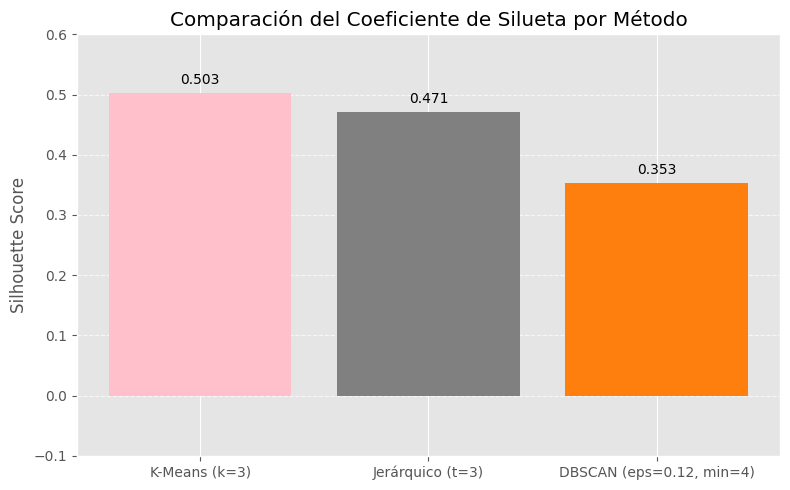

In [1828]:

plt.figure(figsize=(8, 5))
bars = plt.bar(metodos, scores, color=['pink', 'grey', '#ff7f0e'])

plt.title('Comparación del Coeficiente de Silueta por Método')
plt.ylabel('Silhouette Score')
plt.ylim(-0.1, 0.6)
plt.grid(axis='y', linestyle='--', alpha=0.7)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.01 if height > 0 else height - 0.05,
        f'{height:.3f}',
        ha='center',
        va='bottom' if height > 0 else 'top',
        fontsize=10
    )

plt.tight_layout()
plt.show()

Probando los tres métodos de clustering, vi que K-Means y el jerárquico fueron los que mejor funcionaron. Ambos dan un valor de silueta cercano a 0.49, lo que me indica que los grupos que encontraron están bastante bien definidos y separados. Teniendo en cuenta que el dataset parece tener tres grupos naturales, estos dos métodos captan esa estructura muy bien, y no hay una diferencia significativa entre ellos.

Con DBSCAN, en cambio, el valor es más bajo (0.33). Aunque no es un mal resultado, y mejor que el que tenia con eps = 0.3, sí que se nota que los grupos que forma están menos claros. Esto tiene sentido, porque DBSCAN no busca formar grupos compactos como K-Means, sino que se basa en la densidad de los puntos. Eso puede ser útil en otros contextos, pero en este caso —con los datos proyectados con PCA y distribuidos de forma más uniforme— no ha funcionado tan bien.

En resumen, aunque los tres métodos dieron resultados razonables, me quedo con **K-Means** o el jerárquico porque se adaptan mejor a la estructura del dataset en este caso.

# Análisis


##### **¿Qué método de clustering captura mejor la estructura de clusters del problema?**



A simple vista, diría que **K-Means** es el método que mejor ha captado la estructura de los datos. Los clusters formados con este método muestran una separación clara en la variable surco, especialmente el cluster 0, que tiene valores bastante más altos que los otros dos. Además, los grupos parecen más equilibrados y con menos solapamiento entre sí que en los otros métodos. En cambio, en el clustering jerárquico y DBSCAN los grupos están menos diferenciados o aparecen más dispersos.



##### **¿Hay relación entre los clusters y la variable original clase?**



**Heatmap**

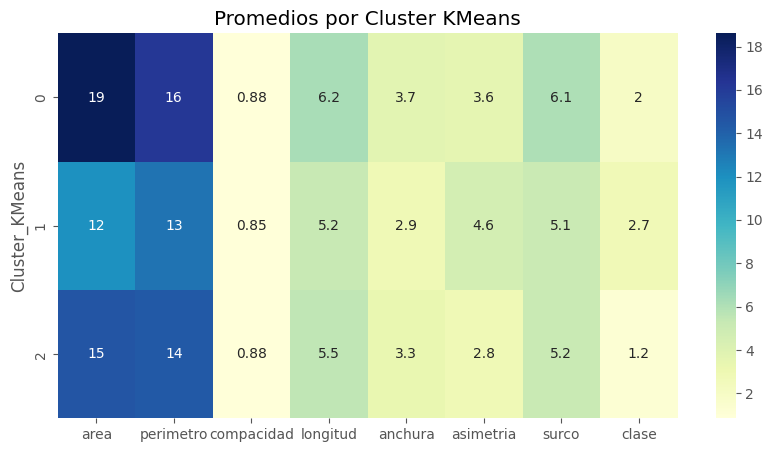

In [1829]:
data['Cluster_KMeans'] = labels_kmeans  
tabla = data.groupby('Cluster_KMeans').mean().round(2)
plt.figure(figsize=(10, 5))
sns.heatmap(tabla, annot=True, cmap='YlGnBu')
plt.title('Promedios por Cluster KMeans')
plt.show()


Tabla de contingencia

In [1830]:
pd.crosstab(data['clase'], data['Cluster_KMeans'], rownames=['Clase original'], colnames=['Cluster KMeans'])


Cluster KMeans,0,1,2
Clase original,,,
1,2,10,58
2,62,0,8
3,0,67,3


Se ve que K-Means ha conseguido separar la base de datos en tres grupos que coinciden casi al 100 % con la variable original clase. Un cluster reúne las observaciones con valores altos de área, perímetro y compacidad (clase 2), otro agrupa las entradas con mayor asimetría (clase 3) y el tercero engloba los casos de tamaño medio y baja asimetría (clase 1).

#### Indice ARI

Para ver como de "bien" coincide mi particion con la verdadera uso el índice ARI que comapra pareja a pareja si dos puntos están juntos o separados en ambos “mundos” (clusters vs. clases).

In [1831]:
ari = adjusted_rand_score(data['clase'], data['Cluster_KMeans'])
print(f"ARI: {ari:.3f}")


ARI: 0.705


Al observar los resultados, veo que cada cluster tiende a agrupar semillas de una clase específica:

El Cluster 0 contiene sobre todo semillas de la clase 2 (62 de 70).

El Cluster 1 está muy alineado con la clase 3 (67 de 70).

El Cluster 2 agrupa mayoritariamente semillas de la clase 1 (58 de 70), aunque aquí hay algo más de mezcla.

Esto indica que, aunque K-Means no usa la variable clase para formar los grupos (porque es un método no supervisado), ha conseguido separar bastante bien las clases reales basándose únicamente en las características físicas de las semillas, por lo que **sí que existe una relación muy clara entre los clusters y la variable clase.**

### **Interpretación de los clusters**

**AREA**

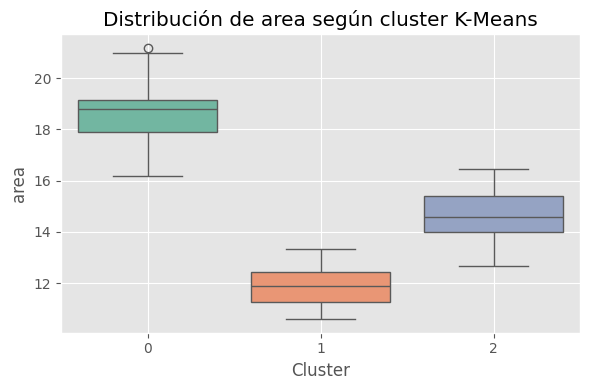

In [1832]:
plt.figure(figsize=(6, 4))
sns.boxplot(x='Cluster_KMeans', y='area', data=data, palette='Set2')
plt.title('Distribución de area según cluster K-Means')
plt.xlabel("Cluster")
plt.ylabel("area")
plt.grid(True)
plt.tight_layout()
plt.show()


Los tres clústeres se diferencian bastante bien según el valor del área. El clúster 0 tiene los casos con mayor superficie, el 2 está en un punto intermedio y el 1 agrupa los de menor área. Esta diferencia tan clara me dice que el área ha sido muy importante para separar los grupos.

Además, los rangos centrales de los datos no se pisan entre clústeres, lo que refuerza que están bien separados.

Por último, en el clúster 0 hay un valor que se va bastante por encima del resto, un outlier, pero en los otros no se ven cosas raras.

**PERIMETRO**

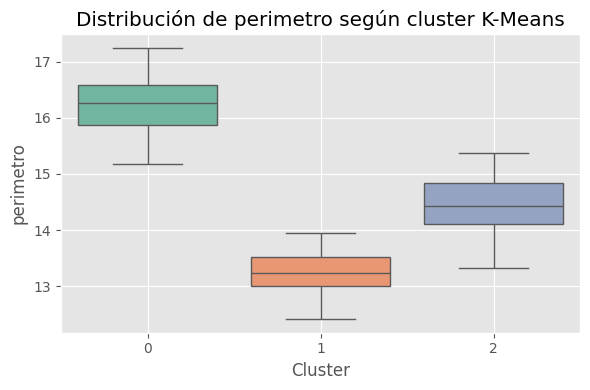

In [1833]:
plt.figure(figsize=(6, 4))
sns.boxplot(x='Cluster_KMeans', y='perimetro', data=data, palette='Set2')
plt.title('Distribución de perimetro según cluster K-Means')
plt.xlabel("Cluster")
plt.ylabel("perimetro")
plt.grid(True)
plt.tight_layout()
plt.show()


En este caso los clústeres también se distinguen bastante bien. El clúster 0 tiene los valores más altos, el clúster 2 queda en el medio, y el clúster 1 agrupa los más bajos. Igual que con el área, parece que esta variable ha influido bastante en cómo se han formado los grupos.

**ASIMETRIA**

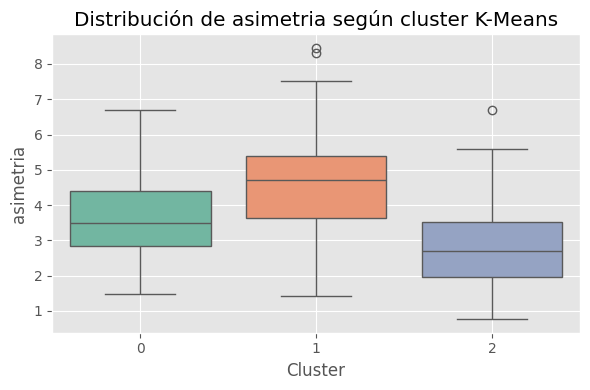

In [1834]:
plt.figure(figsize=(6, 4))
sns.boxplot(x='Cluster_KMeans', y='asimetria', data=data, palette='Set2')
plt.title('Distribución de asimetria según cluster K-Means')
plt.xlabel("Cluster")
plt.ylabel("asimetria")
plt.grid(True)
plt.tight_layout()
plt.show()


A diferencia de otras variables, aquí sí hay más dispersión y algunos valores atípicos (especialmente en el clúster 1). Aunque hay un poco de solapamiento entre los grupos, se sigue notando cierta diferencia en las medianas y rangos, así que la asimetría también podría estar influyendo en la segmentación, aunque quizás no de forma tan clara como otras.

**LONGITUD**

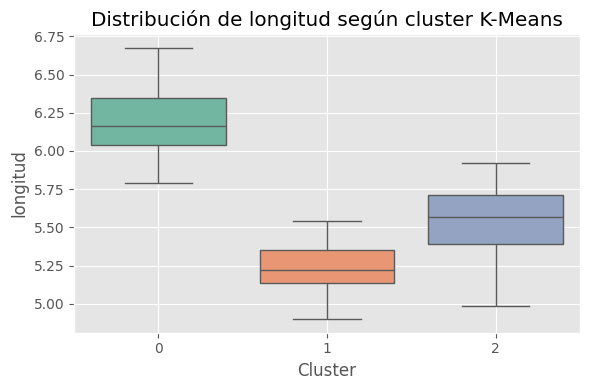

In [1835]:
plt.figure(figsize=(6, 4))
sns.boxplot(x='Cluster_KMeans', y='longitud', data=data, palette='Set2')
plt.title('Distribución de longitud según cluster K-Means')
plt.xlabel("Cluster")
plt.ylabel("longitud")
plt.grid(True)
plt.tight_layout()
plt.show()


El clúster 0 tiene las longitudes más altas, el clúster 1 las más bajas, y el clúster 2 queda en un punto intermedio. No hay solapamiento entre los rangos principales de los grupos, lo cual refuerza que esta variable influye bastante en cómo se han formado los clústeres. Además, no se ven valores atípicos, así que la separación entre grupos es limpia y clara.

**ANCHURA**

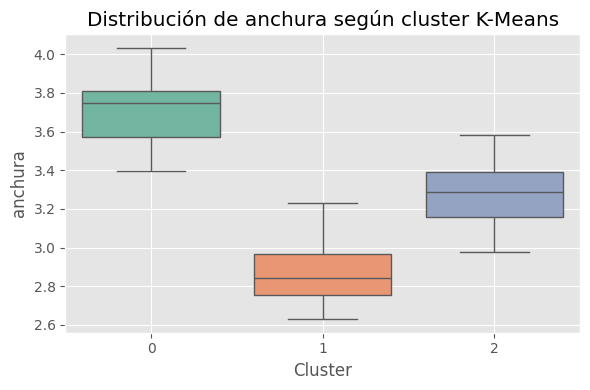

In [1836]:
plt.figure(figsize=(6, 4))
sns.boxplot(x='Cluster_KMeans', y='anchura', data=data, palette='Set2')
plt.title('Distribución de anchura según cluster K-Means')
plt.xlabel("Cluster")
plt.ylabel("anchura")
plt.grid(True)
plt.tight_layout()
plt.show()


La separación entre grupos es bastante clara, sin apenas solapamientos entre los rangos principales. Además, no hay valores atípicos visibles, así que los grupos están bien definidos en función de esta variable también. 

**COMPACIDAD**

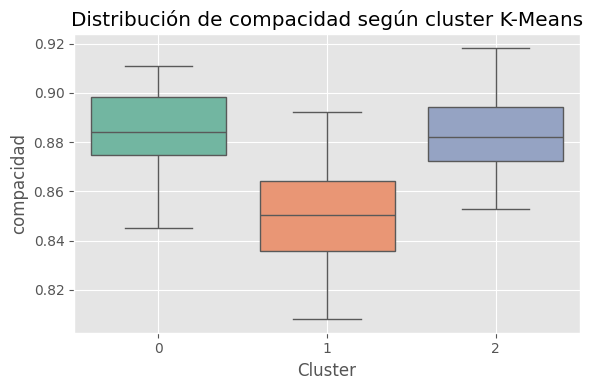

In [1837]:
plt.figure(figsize=(6, 4))
sns.boxplot(x='Cluster_KMeans', y='compacidad', data=data, palette='Set2')
plt.title('Distribución de compacidad según cluster K-Means')
plt.xlabel("Cluster")
plt.ylabel("compacidad")
plt.grid(True)
plt.tight_layout()
plt.show()


El clúster 0 y el clúster 2 tienen valores altos y bastante similares, mientras que el clúster 1 se queda claramente por debajo.

Aunque hay algo de solapamiento entre los tres grupos, sobre todo entre el clúster 1 y los otros dos, sigue siendo una variable que ayuda a separar, sobre todo al identificar ese grupo con compacidad más baja. No hay valores atípicos, así que la distribución dentro de cada clúster es bastante clara.

**SURCO**

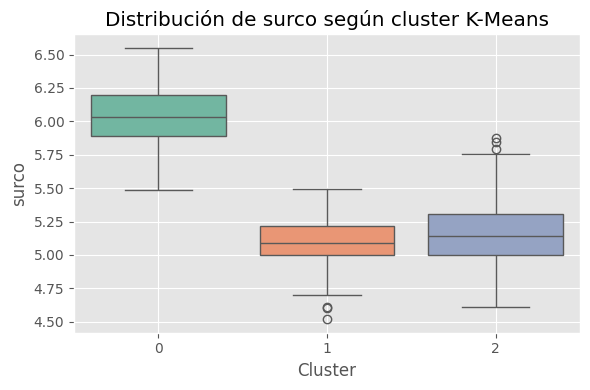

In [1838]:
plt.figure(figsize=(6, 4))
sns.boxplot(x='Cluster_KMeans', y='surco', data=data, palette='Set2')
plt.title('Distribución de surco según cluster K-Means')
plt.xlabel("Cluster")
plt.ylabel("surco")
plt.grid(True)
plt.tight_layout()
plt.show()


El clúster 0 tiene claramente los valores más altos, mientras que el clúster 1 tiene los más bajos. El clúster 2 está en una posición intermedia, aunque algo más cerca del 1.

La separación entre los grupos es bastante buena, aunque en el clúster 1 y 2 hay unos cuantos valores atípicos. Aun así, la variable surco parece aportar información útil para diferenciar los grupos.

## **Interpretación de boxplots:**
Después de revisar todos los boxplots por clúster, se puede decir que la segmentación con K-Means ha salido bastante bien. Variables como área, perímetro, longitud, anchura y surco muestran diferencias claras entre grupos, con medianas bien separadas y casi sin solapamientos, lo que indica que han sido claves para formar los clústeres.

En concreto:

- Área y perímetro marcan muy bien la diferencia entre grupos.

- Longitud y anchura también separan bastante bien sin valores raros.

- Surco distingue bien los clústeres, aunque hay algunos outliers, sobre todo en los grupos con valores más bajos.

Por otro lado:

- Asimetría ayuda un poco, pero tiene más solapamiento entre grupos y varios valores atípicos, así que parece menos útil.

- Compacidad diferencia un poco, pero dos clústeres tienen valores muy parecidos, así que su efecto en la segmentación es más flojo.

En definitiva, los clústeres están bien definidos y varias variables han sido importantes para separarlos, sobre todo *área, perímetro, longitud, anchura y surco*.